# Data Processing: Airport-Specific Weather-Disruption Filtering

This notebook section prepares the cleaned flight dataset for later delay-time modeling. The main goal is to identify and remove abnormal **weather-disruption airport-dates** so that later models can estimate delay under more normal operating conditions.

We use **airport-specific cutoffs** because LAX, SFO, and SAN may have different baseline weather-delay patterns. A weather-delay value that is abnormal for LAX may be normal for SAN, and vice versa.


## 1. Load the cleaned flight data

The dataset is loaded from Google Drive using the usual course project route:

```python
DATA_DIR = "/content/drive/MyDrive"
```


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

DATA_DIR = '/content/drive/MyDrive'

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv(DATA_DIR + "/cleaned_flights.csv")
df["date"] = pd.to_datetime(df["date"])

print("Dataset shape:", df.shape)
print("Date range:", df["date"].min(), "to", df["date"].max())
print("Origin airports:", sorted(df["origin_airport"].dropna().unique()))
print("Airlines:", sorted(df["carrier_code"].dropna().unique()))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset shape: (287386, 22)
Date range: 2025-01-01 00:00:00 to 2026-02-28 00:00:00
Origin airports: ['LAX', 'SAN', 'SFO']
Airlines: ['AA', 'AS', 'B6', 'DL', 'UA']


## 2. Basic data description

Before identifying weather-disruption periods, we summarize the whole dataset and the main delay variables.


In [ ]:
basic_summary = pd.DataFrame({
    "Measure": [
        "Number of flights",
        "Number of origin airports",
        "Number of destination airports",
        "Number of airlines",
        "Average departure delay",
        "Median departure delay",
        "Delay rate",
        "Average weather-attributed delay"
    ],
    "Value": [
        len(df),
        df["origin_airport"].nunique(),
        df["destination_airport"].nunique(),
        df["carrier_code"].nunique(),
        df["departure_delay_minutes"].mean(),
        df["departure_delay_minutes"].median(),
        df["delayed_15"].mean(),
        df["delay_weather_minutes"].mean()
    ]
})

basic_summary

,Measure,Value
0,Number of flights,287386.000000
1,Number of origin airports,3.000000
2,Number of destination airports,82.000000
3,Number of airlines,5.000000
4,Average departure delay,10.386884
5,Median departure delay,-3.000000
6,Delay rate,0.175416
7,Average weather-attributed delay,0.311779


In [ ]:
airport_summary = (
    df.groupby("origin_airport")
    .agg(
        flights=("delayed_15", "size"),
        delay_rate=("delayed_15", "mean"),
        avg_departure_delay=("departure_delay_minutes", "mean"),
        median_departure_delay=("departure_delay_minutes", "median"),
        avg_weather_delay=("delay_weather_minutes", "mean"),
        total_weather_delay=("delay_weather_minutes", "sum"),
        weather_delay_rate=("delay_weather_minutes", lambda x: (x > 0).mean()),
        avg_carrier_delay=("delay_carrier_minutes", "mean"),
        avg_nas_delay=("delay_national_aviation_system_minutes", "mean"),
        avg_security_delay=("delay_security_minutes", "mean"),
        avg_late_aircraft_delay=("delay_late_aircraft_arrival_minutes", "mean")
    )
    .reset_index()
)

airport_summary

,origin_airport,flights,delay_rate,avg_departure_delay,median_departure_delay,avg_weather_delay,total_weather_delay,weather_delay_rate,avg_carrier_delay,avg_nas_delay,avg_security_delay,avg_late_aircraft_delay
0,LAX,126818,0.178295,10.883132,-3.0,0.176465,22379.0,0.001956,5.120093,3.057287,0.020068,4.998754
1,SAN,48342,0.174610,10.783004,-3.0,0.930226,44969.0,0.014149,3.968268,3.394440,0.020231,5.243122
2,SFO,112226,0.172509,9.655481,-3.0,0.198287,22253.0,0.003074,3.788810,2.795974,0.004714,5.128999


## 3. Initial airport comparison graphs

These graphs provide a quick overview of departure delay and reported weather-attributed delay across the three origin airports.


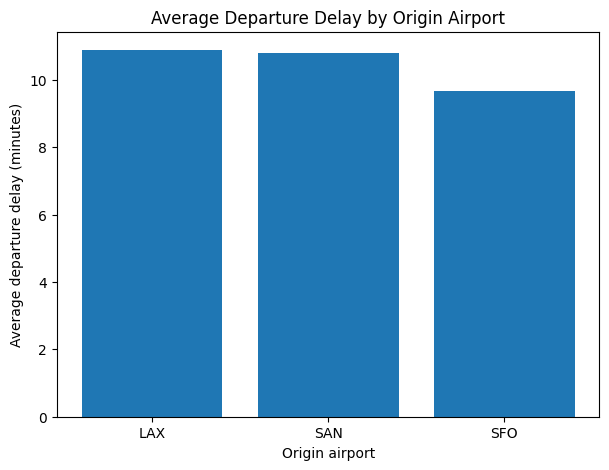

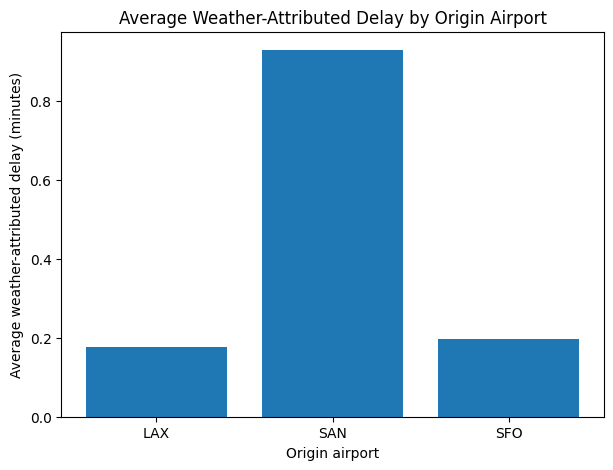

In [ ]:
plt.figure(figsize=(7, 5))
plt.bar(airport_summary["origin_airport"], airport_summary["avg_departure_delay"])
plt.xlabel("Origin airport")
plt.ylabel("Average departure delay (minutes)")
plt.title("Average Departure Delay by Origin Airport")
plt.show()

plt.figure(figsize=(7, 5))
plt.bar(airport_summary["origin_airport"], airport_summary["avg_weather_delay"])
plt.xlabel("Origin airport")
plt.ylabel("Average weather-attributed delay (minutes)")
plt.title("Average Weather-Attributed Delay by Origin Airport")
plt.show()

## 4. Aggregate data by airport and date

We identify weather disruption at the **airport-date** level rather than the individual-flight level.

This is because severe weather can affect many flights at the same airport on the same day. Some flights may have positive `delay_weather_minutes`, while other flights may be indirectly affected through late-arriving aircraft or airport congestion.


In [ ]:
airport_daily = (
    df.groupby(["origin_airport", "date"])
    .agg(
        flights=("delayed_15", "size"),
        delay_rate=("delayed_15", "mean"),
        avg_departure_delay=("departure_delay_minutes", "mean"),
        total_departure_delay=("departure_delay_minutes", "sum"),
        avg_weather_delay=("delay_weather_minutes", "mean"),
        total_weather_delay=("delay_weather_minutes", "sum"),
        weather_delay_rate=("delay_weather_minutes", lambda x: (x > 0).mean()),
        avg_carrier_delay=("delay_carrier_minutes", "mean"),
        avg_nas_delay=("delay_national_aviation_system_minutes", "mean"),
        avg_security_delay=("delay_security_minutes", "mean"),
        avg_late_aircraft_delay=("delay_late_aircraft_arrival_minutes", "mean")
    )
    .reset_index()
)

airport_daily = airport_daily.sort_values(["origin_airport", "date"])

# Centered 3-day rolling average within each airport
airport_daily["weather_3day_avg"] = (
    airport_daily
    .groupby("origin_airport")["avg_weather_delay"]
    .transform(lambda x: x.rolling(window=3, center=True, min_periods=2).mean())
)

airport_daily.head()

,origin_airport,date,flights,delay_rate,avg_departure_delay,total_departure_delay,avg_weather_delay,total_weather_delay,weather_delay_rate,avg_carrier_delay,avg_nas_delay,avg_security_delay,avg_late_aircraft_delay,weather_3day_avg
0,LAX,2025-01-01,291,0.144330,4.896907,1425.0,0.000000,0.0,0.00000,2.663230,0.721649,0.000000,1.938144,0.000000
1,LAX,2025-01-02,318,0.147799,6.097484,1939.0,0.000000,0.0,0.00000,5.342767,0.569182,0.000000,1.905660,0.000000
2,LAX,2025-01-03,313,0.246006,11.297125,3536.0,0.000000,0.0,0.00000,5.817891,2.006390,0.051118,3.699681,0.143503
3,LAX,2025-01-04,295,0.250847,11.759322,3469.0,0.430508,127.0,0.00678,3.450847,1.006780,0.000000,5.701695,0.143503
4,LAX,2025-01-05,312,0.256410,20.416667,6370.0,0.000000,0.0,0.00000,7.730769,6.814103,0.000000,8.067308,0.309043


## 5. Use airport-specific weather-disruption cutoffs

Instead of one shared cutoff for all airports, we calculate cutoffs separately for each airport.

For each airport, an airport-date is classified as a weather-disruption period if:

1. its 3-day average weather-attributed delay is above that airport's 95th percentile, and  
2. its average departure delay is above that airport's 75th percentile.

This compares each airport-date against the normal pattern for the same airport.


In [ ]:
airport_daily["weather_cutoff_airport"] = (
    airport_daily
    .groupby("origin_airport")["weather_3day_avg"]
    .transform(lambda x: x.quantile(0.95))
)

airport_daily["delay_cutoff_airport"] = (
    airport_daily
    .groupby("origin_airport")["avg_departure_delay"]
    .transform(lambda x: x.quantile(0.75))
)

airport_daily["weather_disruption"] = (
    (airport_daily["weather_3day_avg"] > airport_daily["weather_cutoff_airport"]) &
    (airport_daily["avg_departure_delay"] > airport_daily["delay_cutoff_airport"])
)

weather_disruption_dates = airport_daily[
    airport_daily["weather_disruption"]
].copy()

cutoff_table = (
    airport_daily
    .groupby("origin_airport")
    .agg(
        weather_cutoff_airport=("weather_cutoff_airport", "first"),
        delay_cutoff_airport=("delay_cutoff_airport", "first"),
        weather_disruption_dates=("weather_disruption", "sum")
    )
    .reset_index()
)

cutoff_table

,origin_airport,weather_cutoff_airport,delay_cutoff_airport,weather_disruption_dates
0,LAX,0.841036,14.826580,10
1,SAN,4.844194,14.527470,16
2,SFO,0.859619,12.741056,8


## 6. Inspect severe examples that will be excluded

The table below shows the most severe airport-dates identified by the filtering rule.


In [ ]:
weather_disruption_examples = (
    weather_disruption_dates[
        [
            "origin_airport",
            "date",
            "flights",
            "delay_rate",
            "avg_departure_delay",
            "delay_cutoff_airport",
            "avg_weather_delay",
            "weather_3day_avg",
            "weather_cutoff_airport",
            "total_weather_delay",
            "avg_nas_delay",
            "avg_late_aircraft_delay"
        ]
    ]
    .sort_values(["avg_departure_delay"], ascending=False)
)

weather_disruption_examples.head(15)

,origin_airport,date,flights,delay_rate,avg_departure_delay,delay_cutoff_airport,avg_weather_delay,weather_3day_avg,weather_cutoff_airport,total_weather_delay,avg_nas_delay,avg_late_aircraft_delay
426,SAN,2025-01-03,121,0.785124,114.487603,14.527470,2.471074,6.349437,4.844194,299.0,4.330579,86.090909
684,SAN,2025-09-18,126,0.746032,100.269841,14.527470,8.738095,5.150380,4.844194,1101.0,19.222222,61.785714
776,SAN,2025-12-19,123,0.634146,100.186992,14.527470,26.113821,9.451069,4.844194,3212.0,6.056911,54.764228
789,SAN,2026-01-01,111,0.504505,77.891892,14.527470,3.792793,6.892989,4.844194,421.0,2.216216,51.369369
891,SFO,2025-02-13,259,0.575290,54.158301,12.741056,3.297297,1.862297,0.859619,854.0,7.266409,33.254826
683,SAN,2025-09-17,115,0.130435,51.765217,14.527470,6.713043,5.150380,4.844194,772.0,9.808696,32.373913
425,SAN,2025-01-02,123,0.252033,47.756098,14.527470,16.577236,6.349437,4.844194,2039.0,2.682927,27.504065
790,SAN,2026-01-02,124,0.419355,46.580645,14.527470,12.629032,5.664825,4.844194,1566.0,4.314516,14.427419
884,SFO,2025-02-06,240,0.454167,38.133333,12.741056,0.325000,0.976515,0.859619,78.0,3.966667,20.991667
461,SAN,2025-02-07,100,0.400000,37.030000,14.527470,14.440000,4.867302,4.844194,1444.0,14.310000,5.320000


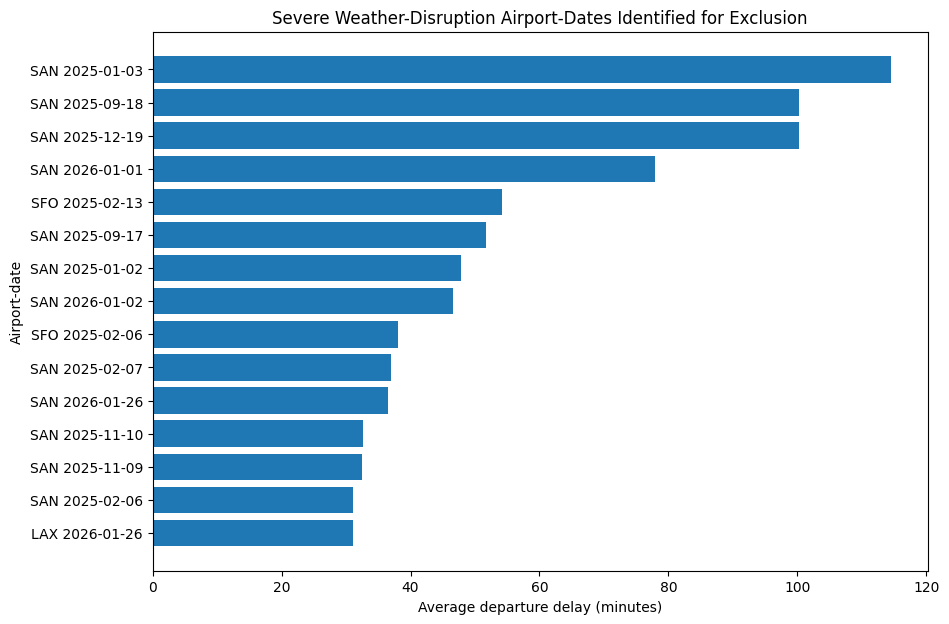

In [ ]:
plot_examples = weather_disruption_examples.head(15).sort_values("avg_departure_delay")

labels = (
    plot_examples["origin_airport"]
    + " "
    + plot_examples["date"].dt.strftime("%Y-%m-%d")
)

plt.figure(figsize=(10, 7))
plt.barh(labels, plot_examples["avg_departure_delay"])
plt.xlabel("Average departure delay (minutes)")
plt.ylabel("Airport-date")
plt.title("Severe Weather-Disruption Airport-Dates Identified for Exclusion")
plt.show()

## 7. Weather-attributed delay over time by airport

To make the graphs easier to compare, the following plots use the same y-axis scale across airports. Each airport's own cutoff is shown with a dashed horizontal line.


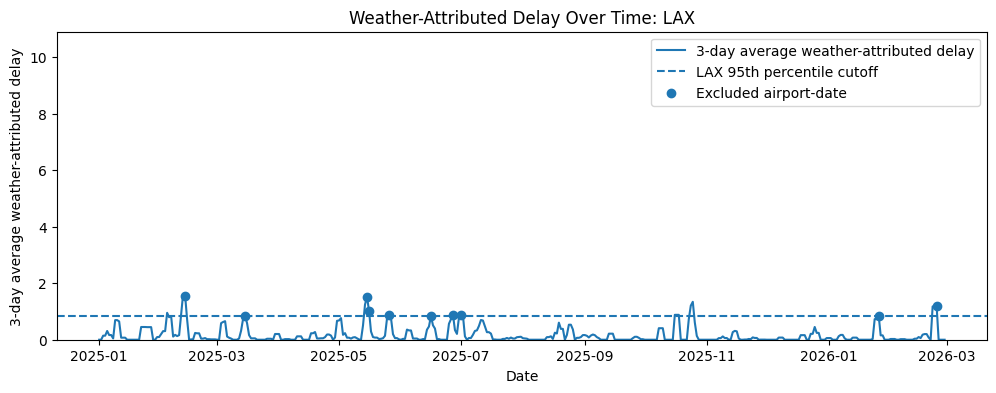

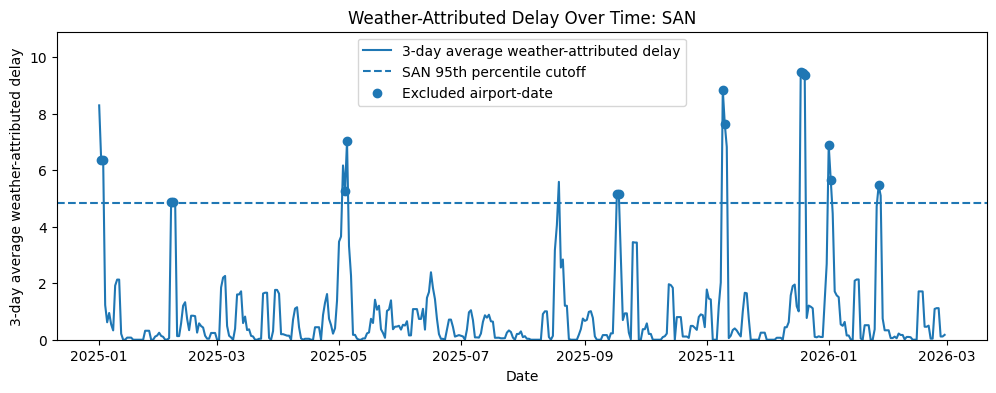

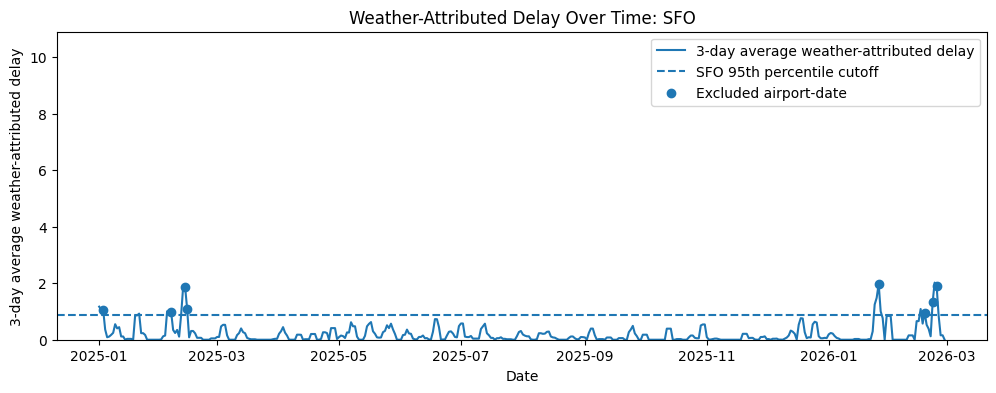

In [ ]:
weather_ymax = max(
    airport_daily["weather_3day_avg"].max(),
    airport_daily["weather_cutoff_airport"].max()
) * 1.15

for airport in sorted(airport_daily["origin_airport"].unique()):
    subset = airport_daily[airport_daily["origin_airport"] == airport].copy()
    cutoff = subset["weather_cutoff_airport"].iloc[0]

    plt.figure(figsize=(12, 4))
    plt.plot(subset["date"], subset["weather_3day_avg"], label="3-day average weather-attributed delay")
    plt.axhline(cutoff, linestyle="--", label=f"{airport} 95th percentile cutoff")

    flagged = subset[subset["weather_disruption"]]
    plt.scatter(flagged["date"], flagged["weather_3day_avg"], label="Excluded airport-date")

    plt.ylim(0, weather_ymax)
    plt.xlabel("Date")
    plt.ylabel("3-day average weather-attributed delay")
    plt.title(f"Weather-Attributed Delay Over Time: {airport}")
    plt.legend()
    plt.show()

## 8. Create the filtered dataset

We remove all flights from airport-dates classified as weather-disruption periods. The resulting dataset is intended to represent more normal operating conditions.


In [ ]:
bad_airport_dates = weather_disruption_dates[
    ["origin_airport", "date"]
].copy()

df_filtered = df.merge(
    bad_airport_dates.assign(weather_disruption_period=1),
    on=["origin_airport", "date"],
    how="left"
)

df_no_weather_disruption = df_filtered[
    df_filtered["weather_disruption_period"].isna()
].copy()

df_no_weather_disruption = df_no_weather_disruption.drop(
    columns=["weather_disruption_period"]
)

print("Original flights:", len(df))
print("After excluding weather-disruption periods:", len(df_no_weather_disruption))
print("Removed flights:", len(df) - len(df_no_weather_disruption))
print("Percent removed:", (len(df) - len(df_no_weather_disruption)) / len(df) * 100)

Original flights: 287386
After excluding weather-disruption periods: 280387
Removed flights: 6999
Percent removed: 2.4354004718392686


## 9. Weather-attributed delay comparison before and after filtering

Instead of only comparing average departure delay, we also directly compare weather-attributed delay before and after filtering. This helps verify that the filter actually removes airport-date periods with unusually high reported weather delay.


In [ ]:
weather_comparison = pd.DataFrame({
    "Dataset": ["Full dataset", "Excluding weather-disruption periods"],
    "Number of flights": [len(df), len(df_no_weather_disruption)],
    "Average weather-attributed delay": [
        df["delay_weather_minutes"].mean(),
        df_no_weather_disruption["delay_weather_minutes"].mean()
    ],
    "Median weather-attributed delay": [
        df["delay_weather_minutes"].median(),
        df_no_weather_disruption["delay_weather_minutes"].median()
    ],
    "Total weather-attributed delay": [
        df["delay_weather_minutes"].sum(),
        df_no_weather_disruption["delay_weather_minutes"].sum()
    ],
    "Share of flights with weather-attributed delay": [
        (df["delay_weather_minutes"] > 0).mean(),
        (df_no_weather_disruption["delay_weather_minutes"] > 0).mean()
    ],
    "Average departure delay": [
        df["departure_delay_minutes"].mean(),
        df_no_weather_disruption["departure_delay_minutes"].mean()
    ],
    "Delay rate": [
        df["delayed_15"].mean(),
        df_no_weather_disruption["delayed_15"].mean()
    ]
})

weather_comparison

,Dataset,Number of flights,Average weather-attributed delay,Median weather-attributed delay,Total weather-attributed delay,Share of flights with weather-attributed delay,Average departure delay,Delay rate
0,Full dataset,287386,0.311779,0.0,89601.0,0.004444,10.386884,0.175416
1,Excluding weather-disruption periods,280387,0.238634,0.0,66910.0,0.003734,9.884428,0.172066


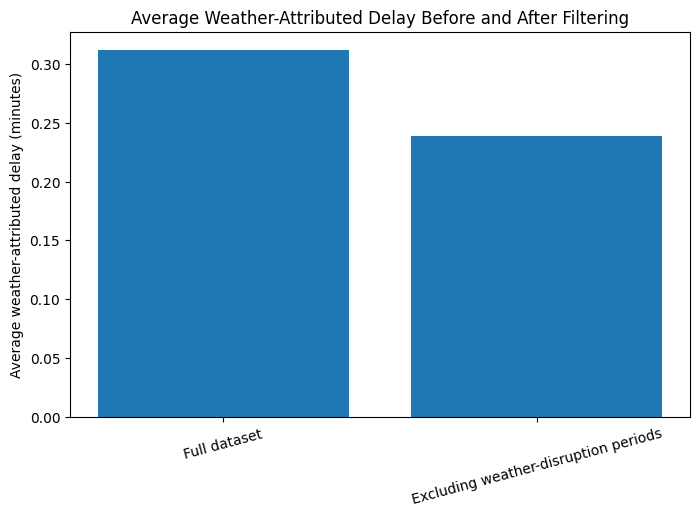

In [ ]:
plt.figure(figsize=(8, 5))
plt.bar(
    weather_comparison["Dataset"],
    weather_comparison["Average weather-attributed delay"]
)
plt.ylabel("Average weather-attributed delay (minutes)")
plt.title("Average Weather-Attributed Delay Before and After Filtering")
plt.xticks(rotation=15)
plt.show()

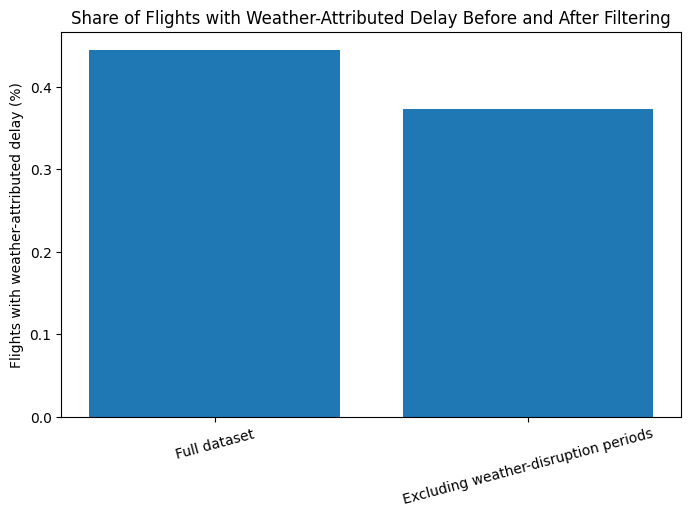

In [ ]:
plt.figure(figsize=(8, 5))
plt.bar(
    weather_comparison["Dataset"],
    weather_comparison["Share of flights with weather-attributed delay"] * 100
)
plt.ylabel("Flights with weather-attributed delay (%)")
plt.title("Share of Flights with Weather-Attributed Delay Before and After Filtering")
plt.xticks(rotation=15)
plt.show()

In [ ]:
airport_weather_comparison = (
    pd.concat([
        df.assign(dataset="Full dataset"),
        df_no_weather_disruption.assign(dataset="Excluding weather-disruption periods")
    ])
    .groupby(["dataset", "origin_airport"])
    .agg(
        flights=("delayed_15", "size"),
        avg_weather_delay=("delay_weather_minutes", "mean"),
        total_weather_delay=("delay_weather_minutes", "sum"),
        weather_delay_rate=("delay_weather_minutes", lambda x: (x > 0).mean()),
        avg_departure_delay=("departure_delay_minutes", "mean"),
        delay_rate=("delayed_15", "mean")
    )
    .reset_index()
)

airport_weather_comparison

,dataset,origin_airport,flights,avg_weather_delay,total_weather_delay,weather_delay_rate,avg_departure_delay,delay_rate
0,Excluding weather-disruption periods,LAX,123710,0.152001,18804.0,0.001778,10.565160,0.175879
1,Excluding weather-disruption periods,SAN,46463,0.599617,27860.0,0.011428,9.195446,0.166434
2,Excluding weather-disruption periods,SFO,110214,0.183697,20246.0,0.002686,9.410792,0.170160
3,Full dataset,LAX,126818,0.176465,22379.0,0.001956,10.883132,0.178295
4,Full dataset,SAN,48342,0.930226,44969.0,0.014149,10.783004,0.174610
5,Full dataset,SFO,112226,0.198287,22253.0,0.003074,9.655481,0.172509


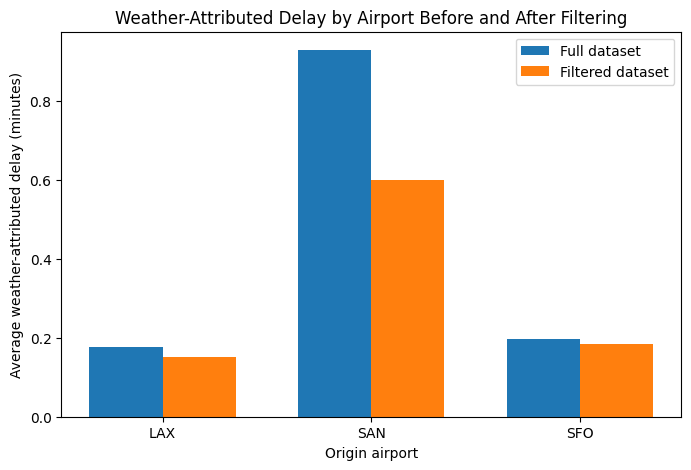

In [ ]:
# Bar chart comparing average weather-attributed delay by airport before and after filtering

pivot_weather = airport_weather_comparison.pivot(
    index="origin_airport",
    columns="dataset",
    values="avg_weather_delay"
).reset_index()

x = np.arange(len(pivot_weather["origin_airport"]))
width = 0.35

plt.figure(figsize=(8, 5))
plt.bar(x - width/2, pivot_weather["Full dataset"], width, label="Full dataset")
plt.bar(x + width/2, pivot_weather["Excluding weather-disruption periods"], width, label="Filtered dataset")

plt.xticks(x, pivot_weather["origin_airport"])
plt.xlabel("Origin airport")
plt.ylabel("Average weather-attributed delay (minutes)")
plt.title("Weather-Attributed Delay by Airport Before and After Filtering")
plt.legend()
plt.show()

The comparison above checks whether the weather-disruption filter is doing what we intended. After filtering, the average weather-attributed delay and the share of flights with weather-attributed delay should decrease, especially for airports with more severe identified disruption periods.


In [ ]:
output_path = DATA_DIR + "/cleaned_flights_no_weather_disruption.csv"

df_no_weather_disruption.to_csv(output_path, index=False)

print("Saved filtered dataset to:", output_path)
print("Filtered dataset shape:", df_no_weather_disruption.shape)